**PA3 Group 65**

**KHAN, Zeeshan Alam**

---

**My Reflection On Annotation Task (Data Labelling)**

**Group For Data Labelling:** Group 38 Annotator 1

**My Analysis**: The labelling and annotation task was interesting, but came with some genuine challenges that made consistent labelling difficult.

The first issue was factual statements carrying an implicit sentiment. Some sentences were structured as objective facts, yet clearly leaned positive or negative in tone. This created a dilemma: label it Neutral because it reads as a fact, or assign a polarity because the implied meaning is obvious? For example:

- *"The battery lasts 3 hours."* stated as a fact, but the implied sentiment is negative
- *"The restaurant has been fully booked every night this week."* objective, but reads as positive

Defaulting to Neutral in these cases felt like losing real signal, but assigning positive or negative introduced subjectivity.

The second challenge was sarcasm, where the literal words say the opposite of the intended meaning. These were especially tricky because the surface language can appear positive while the true sentiment is negative:

- *"Oh great, another update that deleted all my files."* contains "great" but is clearly negative
- *"Nothing says 'relaxing holiday' like a four-hour delay."* framed positively, but expresses frustration

Both challenges point to the same underlying issue: sentiment is not always in the words themselves, but in tone and context, things that are hard to capture with a simple label.

**How to improve labelling:** To improve label quality, two approaches would help. First, introducing an annotation guideline that explicitly addresses edge cases like facts and sarcasm would give labellers a clearer rule to follow, reducing inconsistency. Second, while this task already used two annotators to reduce individual bias, increasing to three or more annotators per sentence would make majority voting more robust, as two annotators can still deadlock on genuinely ambiguous cases.**bold text**

---

**PA3**

First, we have connected Google Drive to our Colab file.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now, we load the Crowdsourced data and display it to check if we have loaded it correctly.

In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/crowdsourced_train.csv'

# Load using tab separator and explicit names to handle formatting issues
df = pd.read_csv(file_path, sep='\t')

display(df.head())

,sentiment,text
0,Positive,There's so much misconception on Islam rn so s...
1,Positive,@Mr_Rondeau You should try Iron Maiden at abou...
2,Negative,Going to #FantasticFour tomorrow. Half expecti...
3,Neutral,"@cfelan hey hey, just checkng to see if you or..."
4,Positive,does anyone just get drunk and watch twilight ...


We began by exploring the Crowdsourced data. First, we checked the "**sentiment**" labels and discovered several spelling mistakes, inconsistent capitalization, and malformed entries, which made it clear that the dataset needed cleaning. This is a highlighted issue that needs solving.



In [3]:
# 1. Check labels
print('Unique labels found:', df['sentiment'].unique())

# 2. Check distribution
label_counts = df['sentiment'].value_counts()

print('\nLabel distribution:')
print(label_counts)

Unique labels found: ['Positive' 'Negative' 'Neutral' 'neutral' 'negative' 'positive'
 'neutral?' 'Nuetral' 'negative ' 'positive ' 'neutral ' ' negative'
 'Nedative' '_x0008_neutral' 'netural' 'netutral' 'Neutral ' 'Neural'
 'Neutrall' 'Netural' 'neugral' 'neutrla' 'negtaive' 'postive'
 '                neutral'
 '                                        positive' '    positive'
 ' neutral' '               negative' 'Nutral' 'negayive' 'positie'
 'neutra l' 'npositive' 'neutal' 'postitive' 'Positve']

Label distribution:
sentiment
neutral                                             2671
Neutral                                             2342
positive                                            1748
Positive                                            1462
negative                                            1396
Negative                                             973
Neutral                                               28
netural                                               14
Netural

Next, we cleaned the sentiment labels by converting them to lowercase, removing extra whitespace, and correcting spelling variations and malformed entries using a manual mapping. After the cleanup, we verified that only the three expected labels remained: negative, neutral, and positive. This is the solution of the issue highlighted above.

In [4]:
import pandas as pd

# 1. Standardize text: lowercase and remove leading/trailing whitespace
df['sentiment'] = df['sentiment'].astype(str).str.lower().str.strip()

# 2. Define a mapping to fix spelling errors and variations
label_map = {
    'positve': 'positive', 'postive': 'positive', 'positie': 'positive',
    'postitive': 'positive', 'npositive': 'positive', 'positle': 'positive',
    'negtaive': 'negative', 'negayive': 'negative', 'nedative': 'negative',
    'negative ': 'negative', ' negative': 'negative',
    'neutral?': 'neutral', 'nuetral': 'neutral', 'netural': 'neutral',
    'netutral': 'neutral', 'neural': 'neutral', 'neutrall': 'neutral',
    'neugral': 'neutral', 'neutrla': 'neutral', 'nutral': 'neutral',
    'neutra l': 'neutral', 'neutal': 'neutral', '_x0008_neutral': 'neutral'
}

# 3. Apply the mapping
df['sentiment'] = df['sentiment'].replace(label_map)

# Create a verification table to ensure no 'dirty' labels remain
verify_crowd = df['sentiment'].unique()

# Create a DataFrame to display the unique labels found in both
verification_df = pd.DataFrame({
    'Source': ['Crowdsourced'],
    'Unique Labels': [sorted(verify_crowd)],
    'Total Unique Count': [len(verify_crowd)]
})

print("Verification Table: Ensuring no extra/dirty values remain")
display(verification_df)

Verification Table: Ensuring no extra/dirty values remain


,Source,Unique Labels,Total Unique Count
0,Crowdsourced,"[negative, neutral, positive]",3


After cleaning the labels, we examined the class distribution and found that the dataset was not perfectly balanced. Neutral was the largest class with 5,079 examples (47.57%), followed by positive with 3,219 examples (30.15%) and negative with 2,378 examples (22.27%). This means the dataset is mildly imbalanced, with neutral texts being the most common and negative texts the least common.

In [5]:

summary_df = df['sentiment'].value_counts().reset_index()
summary_df.columns = ['Sentiment Label', 'Count']
summary_df['Percentage'] = (summary_df['Count'] / len(df) * 100).round(2).astype(str) + '%'

print('Cleaned Sentiment Distribution:')
display(summary_df)

Cleaned Sentiment Distribution:


,Sentiment Label,Count,Percentage
0,neutral,5079,47.57%
1,positive,3219,30.15%
2,negative,2378,22.27%


Now, we load the Gold data and display it to check if we have loaded it correctly.

In [6]:
gold_df = pd.read_csv('/content/drive/MyDrive/gold_train.csv', sep='\t')

gold_df

,sentiment,text
0,neutral,There's so much misconception on Islam rn so s...
1,neutral,@Mr_Rondeau You should try Iron Maiden at abou...
2,neutral,Going to #FantasticFour tomorrow. Half expecti...
3,neutral,"@cfelan hey hey, just checkng to see if you or..."
4,neutral,does anyone just get drunk and watch twilight ...
...,...,...
10671,positive,Glad to hear there may be a bigger more public...
10672,positive,Great stand by the Wolves on 3rd and long. Cur...
10673,negative,Ayyye I just purchased my Ed Sheeran tickets f...
10674,negative,"The anti-semitism, the misogyny, and the suppo..."


In [7]:
# Check unique labels in Gold dataset before cleaning
print('Unique labels found in Gold dataset:', gold_df['sentiment'].unique())

# Check distribution in Gold dataset
gold_label_counts = gold_df['sentiment'].value_counts()
print('\nGold Label distribution:')
print(gold_label_counts)

Unique labels found in Gold dataset: ['neutral' 'positive' 'negative']

Gold Label distribution:
sentiment
neutral     5364
positive    3652
negative    1660
Name: count, dtype: int64


Next, we complete the same cleaning process for the Gold data as we did with the Crowdsourced data. After the cleanup, we verified that only the three expected labels remained: negative, neutral, and positive.

In [8]:
# Apply same cleaning logic to gold data
gold_df['sentiment'] = gold_df['sentiment'].astype(str).str.lower().str.strip()
gold_df['sentiment'] = gold_df['sentiment'].replace(label_map)

print("Gold Dataset Loaded and Cleaned.")
display(gold_df.head())


# Create a verification table to ensure no 'dirty' labels remain
verify_gold = gold_df['sentiment'].unique()

# Create a DataFrame to display the unique labels found in both
verification_df_gold = pd.DataFrame({
    'Source': ['Gold'],
    'Unique Labels': [sorted(verify_gold)],
    'Total Unique Count': [len(verify_gold)]
})

print()
print("Verification Table: Ensuring no extra/dirty values remain")
display(verification_df_gold)



Gold Dataset Loaded and Cleaned.


,sentiment,text
0,neutral,There's so much misconception on Islam rn so s...
1,neutral,@Mr_Rondeau You should try Iron Maiden at abou...
2,neutral,Going to #FantasticFour tomorrow. Half expecti...
3,neutral,"@cfelan hey hey, just checkng to see if you or..."
4,neutral,does anyone just get drunk and watch twilight ...



Verification Table: Ensuring no extra/dirty values remain


,Source,Unique Labels,Total Unique Count
0,Gold,"[negative, neutral, positive]",3


Next, we compared the label distributions in the Crowdsourced and Gold datasets.

In [9]:
import pandas as pd

# Calculate counts for both datasets
crowd_counts = df['sentiment'].value_counts().sort_index()
gold_counts = gold_df['sentiment'].value_counts().sort_index()

# Create a combined summary table
summary_comparison = pd.DataFrame({
    'Crowd Count': crowd_counts,
    'Crowd %': (crowd_counts / len(df) * 100).round(2).astype(str) + '%',
    'Gold Count': gold_counts,
    'Gold %': (gold_counts / len(gold_df) * 100).round(2).astype(str) + '%'
})

print("Label Distribution Comparison: Crowdsourced vs. Gold")
display(summary_comparison)

Label Distribution Comparison: Crowdsourced vs. Gold


,Crowd Count,Crowd %,Gold Count,Gold %
sentiment,,,,
negative,2378,22.27%,1660,15.55%
neutral,5079,47.57%,5364,50.24%
positive,3219,30.15%,3652,34.21%


The comparison between the crowdsourced and gold label distributions shows clear systematic differences. The crowdsourced annotations assign a higher proportion of negative labels (22.27% vs. 15.55%) and a lower proportion of positive labels (30.15% vs. 34.21%) relative to the gold standard, while neutral labels are fairly similar (47.57% vs. 50.24%). This suggests a tendency of the crowdsourced annotator to over-classify instances as negative and under-classify positive sentiment.



---



We will now evaluate how well the crowdsourced labels align with the gold labels using Cohen’s Kappa score. A score of 1 indicates perfect agreement, 0 indicates agreement no better than chance, and -1 indicates complete disagreement, where the two annotations disagree more than would be expected randomly.

In [10]:
from sklearn.metrics import cohen_kappa_score


# Calculate Cohen's Kappa
kappa = cohen_kappa_score(df['sentiment'], gold_df['sentiment'])

print(f"Cohen's Kappa Score: {kappa:.4f}")

Cohen's Kappa Score: 0.4463


The Cohen’s Kappa score of 0.4463 indicates moderate agreement between the two annotators. While this is significantly better than chance, it also highlights substantial inconsistency in labeling decisions. In practical terms, the annotators agree on many cases, but there is still a considerable proportion of disagreements.



---



**Write the code to implement a classifier that determines whether a given text expresses a neutral, positive, or negative sentiment**

To train our classifier, we first convert the raw text into numerical features for both the Crowdsourced and Gold datasets. We use the TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer, which weights words based on how unique they are to specific documents relative to the entire dataset.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Initialize a vectorizer for the crowdsourced and gold data
vectorizer = TfidfVectorizer(stop_words='english')

crowd_tfidf_matrix = vectorizer.fit_transform(df['text'])
gold_tfidf_matrix = vectorizer.fit_transform(gold_df['text'])

crowd_feature_names = vectorizer.get_feature_names_out()
gold_feature_names = vectorizer.get_feature_names_out()

print(f"Crowdsourced TF-IDF Matrix Shape: {crowd_tfidf_matrix.shape}")
print(f"Gold TF-IDF Matrix Shape: {gold_tfidf_matrix.shape}")

Crowdsourced TF-IDF Matrix Shape: (10676, 22633)
Gold TF-IDF Matrix Shape: (10676, 22633)


After vectorization, we compare the dimensions of our original dataframes with the resulting TF-IDF matrices to ensure the number of rows matches.

In [12]:
# Get original shape of DF
balanced_crowd_shape = df.shape
balanced_gold_shape = gold_df.shape

# Get TF-IDF matrix shape
crowd_matrix_shape = crowd_tfidf_matrix.shape
gold_matrix_shape = gold_tfidf_matrix.shape

print(f"--- Shape Comparison ---")

print()

print(f"Crowdsourced DataFrame Shape: {balanced_crowd_shape} (Rows, Columns)")
print(f"TF-IDF Matrix Shape:      {crowd_matrix_shape} (Rows, Vocabulary Words)")

print()

print(f"Gold DataFrame Shape: {balanced_gold_shape} (Rows, Columns)")
print(f"TF-IDF Matrix Shape:      {gold_matrix_shape} (Rows, Vocabulary Words)")


--- Shape Comparison ---

Crowdsourced DataFrame Shape: (10676, 2) (Rows, Columns)
TF-IDF Matrix Shape:      (10676, 22633) (Rows, Vocabulary Words)

Gold DataFrame Shape: (10676, 2) (Rows, Columns)
TF-IDF Matrix Shape:      (10676, 22633) (Rows, Vocabulary Words)


To verify that our vectorization is working correctly, we can inspect the non-zero TF-IDF scores for the first document in both datasets. This allows us to see which words were extracted and how much weight they were assigned based on their frequency and uniqueness.

In [13]:
# 1. Process Crowdsourced Data
first_row_dense_crowd = crowd_tfidf_matrix[0].toarray().flatten()

word_score_mapping_crowd = pd.DataFrame({
    'Word in Vocabulary': crowd_feature_names,
    'TF-IDF Score (Matrix Value)': first_row_dense_crowd
})

actual_content_crowd = word_score_mapping_crowd[word_score_mapping_crowd['TF-IDF Score (Matrix Value)'] > 0].sort_values(by='TF-IDF Score (Matrix Value)', ascending=False)

print("Crowdsourced: Non-zero entries for Document 0:")
display(actual_content_crowd)

print("\n" + "="*50 + "\n")

# 2. Process Gold Data
first_row_dense_gold = gold_tfidf_matrix[0].toarray().flatten()

word_score_mapping_gold = pd.DataFrame({
    'Word in Vocabulary': gold_feature_names,
    'TF-IDF Score (Matrix Value)': first_row_dense_gold
})

actual_content_gold = word_score_mapping_gold[word_score_mapping_gold['TF-IDF Score (Matrix Value)'] > 0].sort_values(by='TF-IDF Score (Matrix Value)', ascending=False)

print("Gold: Non-zero entries for Document 0:")
display(actual_content_gold)

Crowdsourced: Non-zero entries for Document 0:


,Word in Vocabulary,TF-IDF Score (Matrix Value)
10376,islam,0.399915
13095,misconception,0.361595
9737,hv,0.335440
1218,abt,0.327020
4516,citizens,0.300864
16962,rn,0.290964
19957,thoughts,0.285565
18082,showing,0.266289
7383,fan,0.234533
2499,bad,0.195774




Gold: Non-zero entries for Document 0:


,Word in Vocabulary,TF-IDF Score (Matrix Value)
10376,islam,0.399915
13095,misconception,0.361595
9737,hv,0.335440
1218,abt,0.327020
4516,citizens,0.300864
16962,rn,0.290964
19957,thoughts,0.285565
18082,showing,0.266289
7383,fan,0.234533
2499,bad,0.195774


We will now use GridSearchCV with 5-fold cross-validation to evaluate multiple machine learning models: **Logistic Regression**, **Multinomial Naive Bayes**, and **Random Forest**. This will help us identify the best model and hyperparameters for our sentiment analysis task.

In [14]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Define the models and their hyperparameter grids
model_params = [
    {
        'name': 'Logistic Regression',
        'model': LogisticRegression(max_iter=2000),
        'params': {'C': [0.1, 1, 10], 'solver': ['liblinear', 'lbfgs']}
    },
    {
        'name': 'Naive Bayes',
        'model': MultinomialNB(),
        'params': {'alpha': [0.1, 0.5, 1.0]}
    },
    {
        'name': 'Random Forest',
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
    }
]

# Initialize KFold once with a fixed seed to ensure identical folds for all experiments
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

# Iterate through models and perform GridSearch on Crowdsourced labels
for entry in model_params:
    print(f"Running GridSearch for {entry['name']} (Crowdsourced)...")
    grid = GridSearchCV(entry['model'], entry['params'], cv=kf, scoring='accuracy', n_jobs=-1)
    grid.fit(crowd_tfidf_matrix, df['sentiment'])

    results.append({
        'Model': entry['name'],
        'Best Score': grid.best_score_,
        'Best Params': grid.best_params_
    })

# Display the results
results_df = pd.DataFrame(results).sort_values(by='Best Score', ascending=False)
print("\n--- Model Performance Summary (Crowdsourced Labels) ---")
display(results_df)

Running GridSearch for Logistic Regression (Crowdsourced)...
Running GridSearch for Naive Bayes (Crowdsourced)...
Running GridSearch for Random Forest (Crowdsourced)...

--- Model Performance Summary (Crowdsourced Labels) ---


,Model,Best Score,Best Params
0,Logistic Regression,0.573809,"{'C': 1, 'solver': 'lbfgs'}"
2,Random Forest,0.562289,"{'max_depth': None, 'n_estimators': 200}"
1,Naive Bayes,0.547113,{'alpha': 0.5}


Now, we repeat the hyperparameter tuning process using the Gold labels.

In [15]:
results_gold = []

# Iterate through models and perform GridSearch on Gold labels using the SAME kf object
for entry in model_params:
    print(f"Running GridSearch for {entry['name']} (Gold Labels)...")
    grid = GridSearchCV(entry['model'], entry['params'], cv=kf, scoring='accuracy', n_jobs=-1)
    grid.fit(gold_tfidf_matrix, gold_df['sentiment'])

    results_gold.append({
        'Model': entry['name'],
        'Best Score': grid.best_score_,
        'Best Params': grid.best_params_
    })

# Display the results
results_gold_df = pd.DataFrame(results_gold).sort_values(by='Best Score', ascending=False)
print("\n--- Model Performance Summary (Gold Labels) ---")
display(results_gold_df)

Running GridSearch for Logistic Regression (Gold Labels)...
Running GridSearch for Naive Bayes (Gold Labels)...
Running GridSearch for Random Forest (Gold Labels)...

--- Model Performance Summary (Gold Labels) ---


,Model,Best Score,Best Params
0,Logistic Regression,0.638348,"{'C': 1, 'solver': 'lbfgs'}"
2,Random Forest,0.623642,"{'max_depth': None, 'n_estimators': 200}"
1,Naive Bayes,0.606313,{'alpha': 0.5}


**Final Comparison Summary**

Let's combine the best scores from both the Crowdsourced and Gold models for a final comparison.

In [16]:
# Merge the two results dataframes for comparison
comparison_summary = results_df[['Model', 'Best Score']].rename(columns={'Best Score': 'Crowdsourced Best Score'})
gold_scores = results_gold_df[['Model', 'Best Score']].rename(columns={'Best Score': 'Gold Best Score'})

final_comparison = pd.merge(comparison_summary, gold_scores, on='Model')
display(final_comparison)

,Model,Crowdsourced Best Score,Gold Best Score
0,Logistic Regression,0.573809,0.638348
1,Random Forest,0.562289,0.623642
2,Naive Bayes,0.547113,0.606313


**Loading Test Data**

We are now loading the test.csv file from Google Drive to prepare it for evaluation.

In [17]:
import pandas as pd

test_file_path = '/content/drive/MyDrive/test.csv'

test_df = pd.read_csv(test_file_path, sep='\t')

display(test_df.head())

,sentiment,text
0,neutral,Niall will follow me One Day That day just is...
1,negative,always pull the gay card cause some exgirlfrie...
2,neutral,Fall out of Dar es Salaam draw: Super Eagles m...
3,neutral,Might as well get the Djokovic vs Federer fina...
4,neutral,"After Kevin Anderson to Murray in the 4th set,..."


We will now use the best models (Logistic Regression with best parameters) identified earlier to predict the sentiment of the test data and compare their performance.

In [18]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare Test Data
test_df['sentiment'] = test_df['sentiment'].astype(str).str.lower().str.strip()
test_df['sentiment'] = test_df['sentiment'].replace(label_map)

# Use the vectorizer fitted on training data to transform test data
test_tfidf_matrix = vectorizer.transform(test_df['text'])

# 2. Get Best Models (Logistic Regression was best for both)
best_params_crowd = results_df[results_df['Model'] == 'Logistic Regression']['Best Params'].values[0]
best_params_gold = results_gold_df[results_gold_df['Model'] == 'Logistic Regression']['Best Params'].values[0]

model_crowd = LogisticRegression(max_iter=2000, **best_params_crowd)
model_gold = LogisticRegression(max_iter=2000, **best_params_gold)

# 3. Fit on full training sets
model_crowd.fit(crowd_tfidf_matrix, df['sentiment'])
model_gold.fit(gold_tfidf_matrix, gold_df['sentiment'])

# 4. Predict and Evaluate
preds_crowd = model_crowd.predict(test_tfidf_matrix)
preds_gold = model_gold.predict(test_tfidf_matrix)

acc_crowd = accuracy_score(test_df['sentiment'], preds_crowd)
acc_gold = accuracy_score(test_df['sentiment'], preds_gold)

# 5. Summary
evaluation_results = pd.DataFrame({
    'Training Source': ['Crowdsourced', 'Gold'],
    'Test Accuracy': [acc_crowd, acc_gold]
})

print("Final Model Performance on test.csv:")
display(evaluation_results)

print("\nDetailed Report (Gold-trained model):")
print(classification_report(test_df['sentiment'], preds_gold))

Final Model Performance on test.csv:


,Training Source,Test Accuracy
0,Crowdsourced,0.619479
1,Gold,0.714518



Detailed Report (Gold-trained model):
              precision    recall  f1-score   support

    negative       0.81      0.42      0.55      1077
     neutral       0.67      0.87      0.76      2597
    positive       0.78      0.67      0.72      1850

    accuracy                           0.71      5524
   macro avg       0.75      0.65      0.68      5524
weighted avg       0.73      0.71      0.70      5524



To better understand where our models are succeeding or failing, we generate confusion matrices for both the Crowdsourced-trained and Gold-trained models. This side-by-side comparison allows us to see how the quality of training labels affects the model's ability to distinguish between specific sentiment classes on the test set.

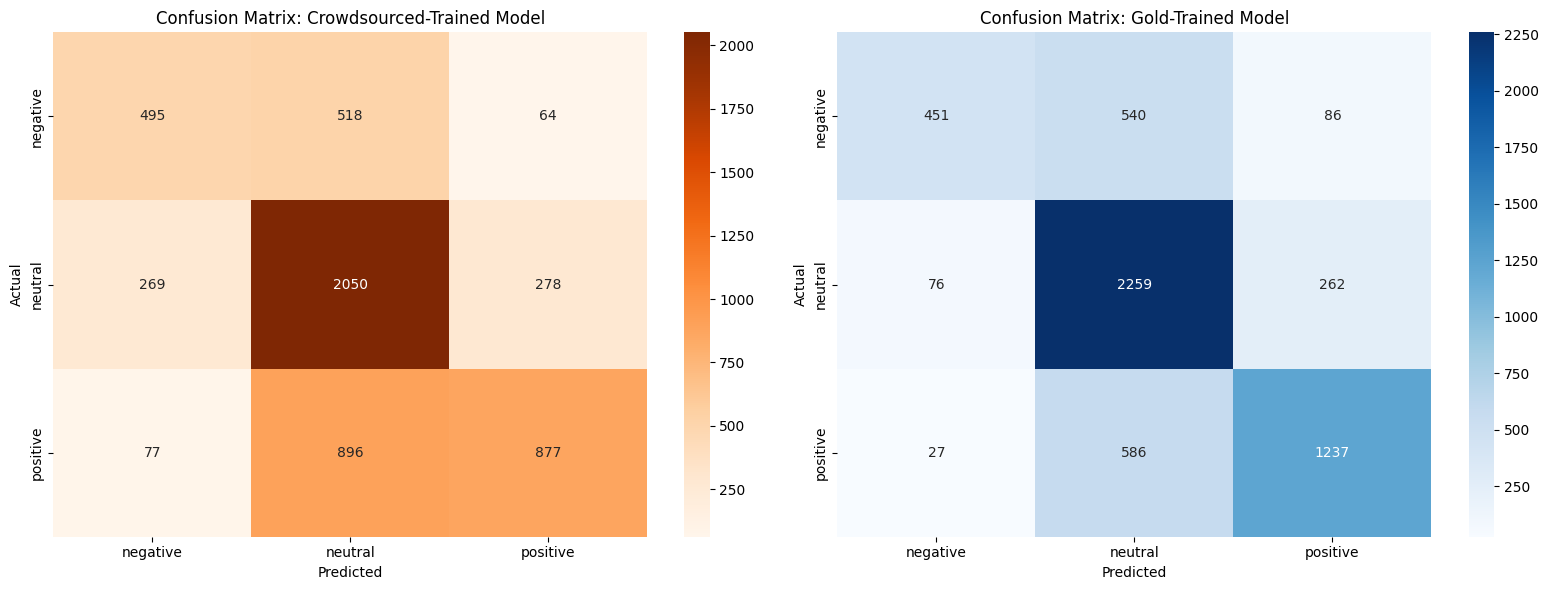

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Compute confusion matrix for the Crowdsourced-trained model
cm_crowd = confusion_matrix(test_df['sentiment'], preds_crowd, labels=['negative', 'neutral', 'positive'])

# 2. Compute confusion matrix for the Gold-trained model
cm_gold = confusion_matrix(test_df['sentiment'], preds_gold, labels=['negative', 'neutral', 'positive'])

# Plotting both side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_crowd, annot=True, fmt='d', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'], cmap='Oranges', ax=ax[0])
ax[0].set_title('Confusion Matrix: Crowdsourced-Trained Model')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')

sns.heatmap(cm_gold, annot=True, fmt='d', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'], cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix: Gold-Trained Model')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

**Feature Importance: Gold vs. Crowdsourced**

We will extract the words with the highest coefficients for both models. Comparing these allows us to see if the models are focusing on the same sentiment-bearing terms.

--- Top Features for Gold Model ---


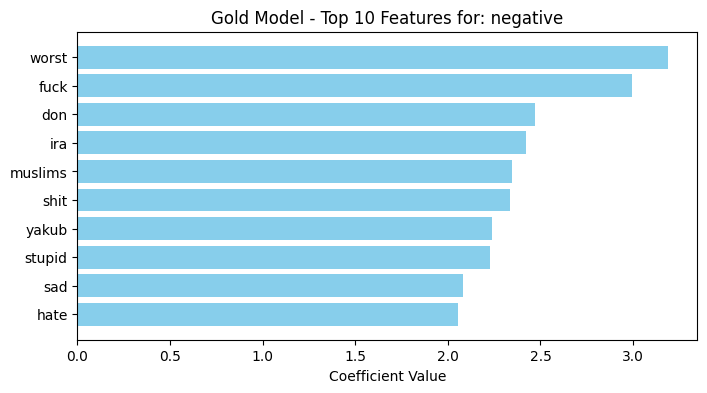

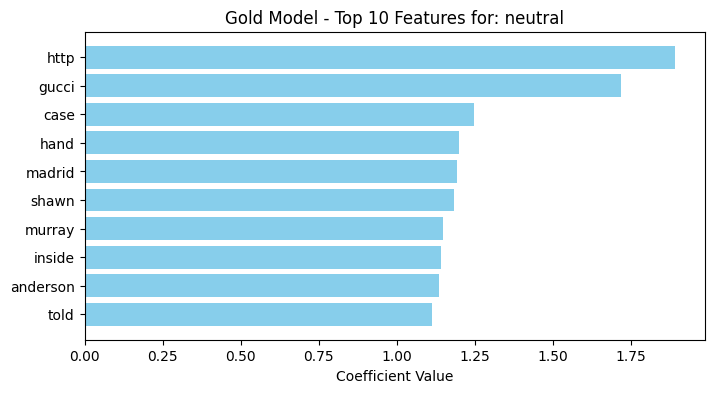

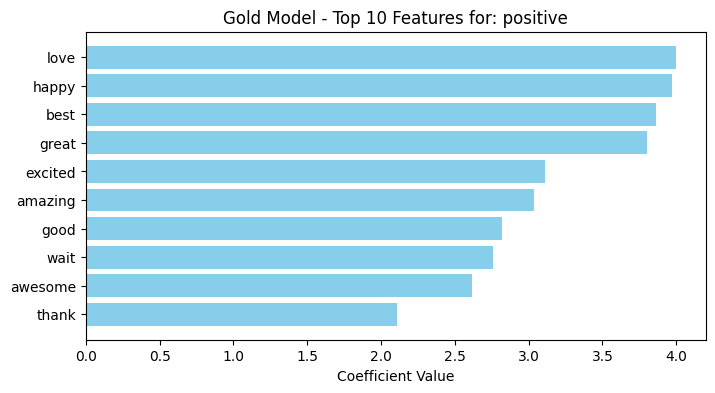



--- Top Features for Crowdsourced Model ---


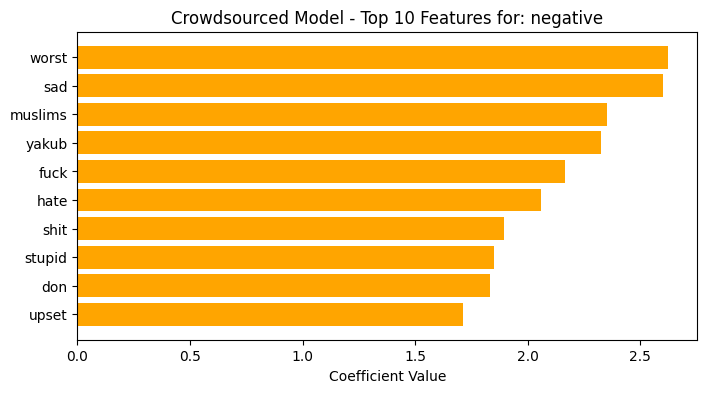

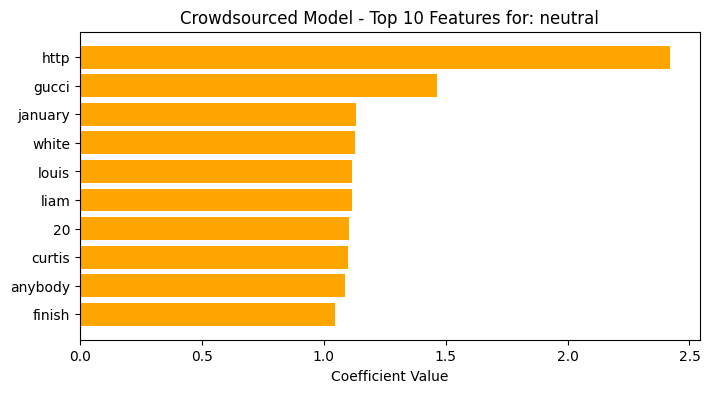

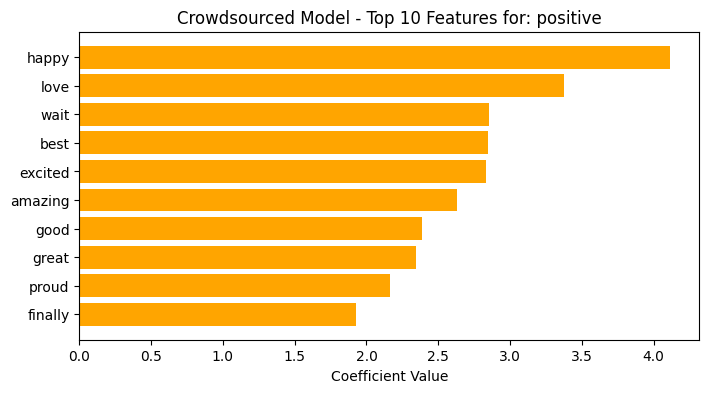

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_top_features(model, vectorizer, model_name, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    classes = model.classes_

    print(f"--- Top Features for {model_name} ---")
    for i, class_label in enumerate(classes):
        top_indices = np.argsort(model.coef_[i])[-top_n:]
        values = model.coef_[i][top_indices]
        labels = [feature_names[idx] for idx in top_indices]

        plt.figure(figsize=(8, 4))
        plt.barh(labels, values, color='skyblue' if model_name == 'Gold Model' else 'orange')
        plt.title(f"{model_name} - Top 10 Features for: {class_label}")
        plt.xlabel("Coefficient Value")
        plt.show()

# Plot features for the Gold-trained model
plot_top_features(model_gold, vectorizer, "Gold Model")

print("\n" + "="*50 + "\n")

# Plot features for the Crowdsourced-trained model
plot_top_features(model_crowd, vectorizer, "Crowdsourced Model")

**Analysis**

The results of this project demonstrate a clear and consistent finding: annotation quality has a measurable and significant impact on classifier performance. The gold-trained Logistic Regression model achieved a test accuracy of 71.45%, compared to 61.95% for the crowdsourced-trained model, a gap of nearly 10 percentage points on otherwise identical data, architecture, and hyperparameters. This difference can be directly attributed to the label noise present in the crowdsourced dataset, as reflected by Cohen's Kappa score of 0.4463. When annotators disagree on roughly a quarter of labels, the model learns a noisier decision boundary, which compounds into weaker generalisation.

A key limitation of the current system is that TF-IDF treats each word independently and ignores word order, context, and negation. A tweet like "not bad at all" shares vocabulary with both positive and negative examples and offers no structural cues to a bag-of-words model. This likely contributes to persistent misclassifications, particularly for the negative class, where sentiment is often expressed indirectly. Pretrained contextual embeddings such as those produced by BERT-based models would be expected to handle these cases more robustly, and this represents the most promising direction for future improvement.

Logistic Regression consistently outperformed both Naive Bayes and Random Forest across both training sets. This is plausible: logistic regression is well-suited to high-dimensional sparse feature spaces like TF-IDF, and its linear decision boundary is often sufficient when features are informative. Naive Bayes performed comparably but makes a strong conditional independence assumption that is unlikely to hold for natural language. Random Forest tends to require denser, lower-dimensional input to perform well and is generally less competitive on raw bag-of-words representations.
